# Telecom Customer Churn Analysis

### Domain: Telecom (Subscription-Based Business)

### Objective

A telecom company is experiencing customer churn across different customer segments.
The objective of this analysis is to quantify churn impact, identify the segments most responsible for revenue loss, and understand the behavioral and contractual drivers of churn.

The analysis focuses on:

* Measuring overall churn and revenue risk
* Identifying high-value customers at risk
* Diagnosing lifecycle and contract-related churn patterns
* Understanding key churn drivers
* Providing data-driven retention recommendations


## Key Business Questions

1. What is the overall churn rate and how much revenue is associated with churned customers?
2. How is revenue distributed across different customer value segments?
3. Are high-value customers more likely to churn compared to other segments?
4. How does contract type influence customer churn?
5. Does customer tenure impact churn behavior?
6. What are the primary reasons customers leave the company?


## Data Preparation & Cleaning

The dataset contains customer demographic information, service usage details, and churn status for telecom subscribers.
Before analysis, missing values and categorical inconsistencies were addressed to ensure accurate segmentation and churn analysis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
df = pd.read_csv("telecom_customer_churn.csv")
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [4]:
pd.set_option('display.max_columns', None)
df.head(2)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.3,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.4,38.33,10,96.21,610.28,Stayed,NaN,NaN


In [5]:
df.shape

(7043, 38)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [7]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [8]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [9]:
df['Avg Monthly Long Distance Charges'] = df["Avg Monthly Long Distance Charges"].fillna(0)
df.head(2)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.3,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.4,38.33,10,96.21,610.28,Stayed,NaN,NaN


In [10]:
df["Multiple Lines"] = df["Multiple Lines"].fillna("No Phone Service")
df.head(2)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.3,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.4,38.33,10,96.21,610.28,Stayed,NaN,NaN


In [11]:
internet_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"]

In [12]:
df["Internet Type"] = df["Internet Type"].fillna("No Internet Services")

In [13]:
df[internet_cols] = df[internet_cols].fillna("No Internet Services")

In [14]:
df["Avg Monthly GB Download"] = df["Avg Monthly GB Download"].fillna(0)

In [15]:
df["Churn Category"] = df["Churn Category"].fillna("Not Churned")
df["Churn Reason"] = df["Churn Reason"].fillna("Not Churned")

In [16]:
df["Offer"] = df["Offer"].fillna("No Offer")

In [17]:
df.isnull().sum()

Customer ID                          0
Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data           

In [18]:
df

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,No Offer,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,Not Churned,Not Churned
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,No Offer,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,Not Churned,Not Churned
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,No Offer,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,0,13,Offer D,Yes,46.68,No,Yes,DSL,59.0,Yes,No,No,Yes,No,No,Yes,Yes,One Year,No,Credit Card,55.15,742.90,0.00,0,606.84,1349.74,Stayed,Not Churned,Not Churned
7039,9992-RRAMN,Male,40,Yes,0,Riverbank,95367,37.734971,-120.954271,1,22,Offer D,Yes,16.20,Yes,Yes,Fiber Optic,17.0,No,No,No,No,No,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,85.10,1873.70,0.00,0,356.40,2230.10,Churned,Dissatisfaction,Product dissatisfaction
7040,9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,0,2,Offer E,Yes,18.62,No,Yes,DSL,51.0,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,50.30,92.75,0.00,0,37.24,129.99,Joined,Not Churned,Not Churned
7041,9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,5,67,Offer A,Yes,2.12,No,Yes,Cable,58.0,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Two Year,No,Credit Card,67.85,4627.65,0.00,0,142.04,4769.69,Stayed,Not Churned,Not Churned


In [19]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

# Baseline Metrics

In [20]:
total_customers = df.shape[0]
total_customers

7043

In [21]:
churned_customers = df[df["Customer Status"] == "Churned"].shape[0]
churned_customers

1869

In [24]:
churn_rate = churned_customers/total_customers
churn_rate

0.2653698707936959

In [23]:
total_revenue = df["Total Revenue"].sum()
total_revenue

np.float64(21371131.69)

In [25]:
revenue_from_churned = df[df["Customer Status"] =="Churned"]["Total Revenue"].sum()
revenue_from_churned

np.float64(3684459.8200000003)

In [26]:
revenue_at_risk_percent = revenue_from_churned/total_revenue
revenue_at_risk_percent

np.float64(0.1724035897324069)

### Although churn rate is relatively high at 26%, revenue impact is proportionally lower 17%, indicating churn is more concentrated among lower-revenue segments. However, $3.68M in lost revenue remains financially significant and warrants targeted retention strategies.

## Feature Engineering

To support segmentation analysis, additional analytical features were created:

* **ARPU (Average Revenue Per User)** – calculated from total revenue and tenure.
* **Value Segment** – customers categorized into Low, Medium, and High value based on ARPU percentiles.
* **Tenure Bucket** – customers grouped into lifecycle stages to analyze early vs long-term churn behavior.

These features allow us to identify revenue concentration and lifecycle-driven churn patterns.


# Value Segmentation

In [27]:
df["ARPU"] = df["Total Revenue"]/ df["Tenure in Months"]
df["ARPU"].describe()

count    7043.000000
mean       88.120156
std        35.910838
min        18.166000
25%        56.765136
50%        93.246364
75%       117.016111
max       190.700000
Name: ARPU, dtype: float64

In [28]:
def value_segment(ARPU):
    if ARPU <=56.765:
        return "low value"
    elif ARPU <= 117.016:
        return "medium value"
    else:
        return "high value"

df["Value_Segment"] = df["ARPU"].apply(value_segment)

In [29]:
df["Value_Segment"].value_counts()

Value_Segment
medium value    3521
high value      1761
low value       1761
Name: count, dtype: int64

### After segmenting customers by ARPU, we analyze revenue contribution by value segment to understand revenue concentration and assess financial dependency on high-value customers.


In [30]:
#Revenue Concentration by Segment

In [32]:
segment_revenue = df.groupby("Value_Segment")["Total Revenue"].sum()
segment_revenue

Value_Segment
high value      9822828.16
low value       2096752.88
medium value    9451550.65
Name: Total Revenue, dtype: float64

In [33]:
segment_revenue_percent = segment_revenue/ total_revenue
segment_revenue_percent

Value_Segment
high value      0.459631
low value       0.098111
medium value    0.442258
Name: Total Revenue, dtype: float64

### The company is financially dependent on high-value customers, and churn within this segment would create significant revenue instability. While overall churn rate is high, revenue concentration suggests that protecting high and medium-value segments should be prioritized over low-value customers.

### churn rate by Value Segment

In [34]:
df["Churn Flag"] = df["Customer Status"].apply(lambda x: 1 if x == "Churned" else 0)

In [35]:
df.groupby("Value_Segment")["Churn Flag"].mean()

Value_Segment
high value      0.333333
low value       0.158433
medium value    0.284862
Name: Churn Flag, dtype: float64

### Although overall revenue at risk appears moderate, segment-level analysis reveals disproportionately high churn among high-value customers, indicating potential instability in core revenue drivers.

In [36]:
def tenure_bucket(months):
    if months <= 6:
        return "0-6 Months"
    elif months <= 24:
        return "7-24 Months"
    else:
        return "25+ Months"

df["Tenure Bucket"] = df["Tenure in Months"].apply(tenure_bucket)

In [37]:
churn_by_value_tenure = df.groupby(["Value_Segment","Tenure Bucket"])["Churn Flag"].mean()
churn_by_value_tenure

Value_Segment  Tenure Bucket
high value     0-6 Months       0.758794
               25+ Months       0.218750
               7-24 Months      0.519108
low value      0-6 Months       0.372685
               25+ Months       0.056582
               7-24 Months      0.149028
medium value   0-6 Months       0.562574
               25+ Months       0.125654
               7-24 Months      0.327103
Name: Churn Flag, dtype: float64

### Churn analysis across tenure buckets reveals that high-value customers experience disproportionately high churn in the first 6 months (~76%). This indicates that revenue instability is primarily driven by early lifecycle attrition rather than long-term customer dissatisfaction. The pattern suggests potential weaknesses in onboarding, pricing alignment, or customer expectation management for premium segments.

In [38]:
#Churn Rate by Contract Type
df.groupby("Contract")["Churn Flag"].mean()

Contract
Month-to-Month    0.458449
One Year          0.107097
Two Year          0.025491
Name: Churn Flag, dtype: float64

### Contract analysis reveals a strong inverse relationship between contract duration and churn rate. Customers on month-to-month contracts exhibit significantly higher churn 46% compared to one-year 11% and two-year 2.5% contracts. This indicates that contractual commitment plays a critical role in revenue stability.

In [39]:
#Churn rate by Value Segment and Contract together.
df.groupby(["Value_Segment", "Contract"])["Churn Flag"].mean()

Value_Segment  Contract      
high value     Month-to-Month    0.574140
               One Year          0.184149
               Two Year          0.049080
low value      Month-to-Month    0.318640
               One Year          0.047619
               Two Year          0.013582
medium value   Month-to-Month    0.465281
               One Year          0.092867
               Two Year          0.019876
Name: Churn Flag, dtype: float64

In [42]:
#Why are High-Value Month-to-Month customers churning?
high_month_to_month_churn = df[
    (df["Value_Segment"] == "high value") &
    (df["Contract"] == "Month-to-Month") &
    (df["Churn Flag"] == 1)
]

In [43]:
high_month_to_month_churn["Churn Category"].value_counts(normalize = True)

Churn Category
Competitor         0.504132
Attitude           0.161157
Dissatisfaction    0.144628
Price              0.111570
Other              0.078512
Name: proportion, dtype: float64

In [44]:
high_month_to_month_churn["Churn Reason"].value_counts().head(20)

Churn Reason
Competitor made better offer                 90
Competitor had better devices                88
Attitude of support person                   59
Competitor offered more data                 39
Don't know                                   27
Competitor offered higher download speeds    27
Price too high                               22
Attitude of service provider                 19
Product dissatisfaction                      17
Service dissatisfaction                      17
Network reliability                          15
Moved                                        11
Long distance charges                        11
Extra data charges                           11
Lack of affordable download/upload speed     10
Limited range of services                    10
Lack of self-service on Website               5
Poor expertise of online support              5
Poor expertise of phone support               1
Name: count, dtype: int64

### Root cause analysis of high-value month-to-month churn reveals that over 50% of attrition is competitor-driven, primarily due to better offers, improved device options, and superior data packages. This suggests that revenue instability in the premium segment is less related to service dissatisfaction and more driven by competitive market pressure combined with low contractual commitment.

## SQL Analysis

To validate the exploratory findings and demonstrate structured query analysis, SQL queries were used to answer the key business questions.
These queries quantify churn magnitude, revenue exposure, and churn patterns across customer segments.


In [45]:
conn = sqlite3.connect("Customer_Churn.db")

In [46]:
df.to_sql('telecom',conn,index = False,if_exists = 'replace')

7043

# Q1.What is the overall churn rate and how many customers churned?

In [47]:
query = """
SELECT 
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Customer Status" = 'Churned' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN "Customer Status" = 'Churned' THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 
        3
    ) AS churn_rate
FROM telecom
"""

pd.read_sql(query, conn)

,total_customers,churned_customers,churn_rate
0,7043,1869,0.265


### Insight: 
The company has a churn rate of approximately 26.5%, indicating that more than one in four customers have discontinued service.

# Q2.How much revenue is lost due to churn?

In [48]:
query = """
SELECT 
    SUM("Total Revenue") AS total_revenue,
    SUM(CASE WHEN "Customer Status" = 'Churned' THEN "Total Revenue" ELSE 0 END) AS revenue_from_churn,
    ROUND(
        SUM(CASE WHEN "Customer Status" = 'Churned' THEN "Total Revenue" ELSE 0 END) * 1.0 /
        SUM("Total Revenue"),
        3
    ) AS revenue_at_risk
FROM telecom
"""
pd.read_sql(query, conn)

,total_revenue,revenue_from_churn,revenue_at_risk
0,21371131.69,3684459.82,0.172


## Insight: 
Although churn rate is relatively high, only 17.2% of revenue is associated with churned customers, indicating churn is somewhat concentrated among lower-value customers.

# Q3.Are high-value customers more likely to churn?

In [49]:
query = """
SELECT 
"Value_Segment",
COUNT(*) AS total_customers,
SUM(CASE WHEN "Customer Status" = 'Churned' THEN 1 ELSE 0 END) AS churned_customers,
ROUND(AVG(CASE WHEN "Customer Status" = 'Churned' THEN 1 ELSE 0 END),3) AS churn_rate
FROM telecom
GROUP BY "Value_Segment"
ORDER BY churn_rate DESC
"""
pd.read_sql(query,conn)

,Value_Segment,total_customers,churned_customers,churn_rate
0,high value,1761,587,0.333
1,medium value,3521,1003,0.285
2,low value,1761,279,0.158


## Insight:
Value segmentation analysis reveals that high-value customers exhibit the highest churn rate (~33%), indicating a disproportionate risk to revenue stability. This suggests that retention strategies should prioritize premium segments, particularly those on flexible contract structures.

# Q4.How does contract type influence churn?

In [50]:
query = """
SELECT 
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Customer Status" = "Churned" THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(AVG(CASE WHEN "Customer Status" = "Churned" THEN 1 ELSE 0 END),3) AS churn_rate
FROM telecom
GROUP BY Contract
ORDER BY churn_rate DESC
"""
pd.read_sql(query,conn)

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-Month,3610,1655,0.458
1,One Year,1550,166,0.107
2,Two Year,1883,48,0.025


## Insight: 
Churn risk is heavily concentrated among month-to-month contracts, suggesting that low contractual commitment significantly increases customer attrition.

# Q5.Does tenure affect churn behavior?

In [51]:
query = """
SELECT
    "Tenure Bucket",
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Customer Status" = "Churned" THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(AVG(CASE WHEN "Customer Status" = "Churned" THEN 1 ELSE 0 END),3) AS churn_rate
FROM telecom
GROUP BY "Tenure Bucket"
ORDER BY churn_rate DESC
"""

pd.read_sql(query,conn)

,Tenure Bucket,total_customers,churned_customers,churn_rate
0,0-6 Months,1470,784,0.533
1,7-24 Months,1740,547,0.314
2,25+ Months,3833,538,0.140


## Insight:
Churn is highest during the early customer lifecycle, with over half of customers leaving within the first six months.

# Q6.What are the main reasons customers churn?

In [52]:
query = """
SELECT
   "Churn Category",
   COUNT(*) AS churned_customers
FROM telecom
WHERE "Customer Status" = 'Churned'
GROUP BY "Churn Category"
ORDER BY churned_customers DESC
"""
pd.read_sql(query,conn)

,Churn Category,churned_customers
0,Competitor,841
1,Dissatisfaction,321
2,Attitude,314
3,Price,211
4,Other,182


## Insight:
More than 45% of churn is competitor-driven, indicating strong competitive pressure in the telecom market.

# EDA 

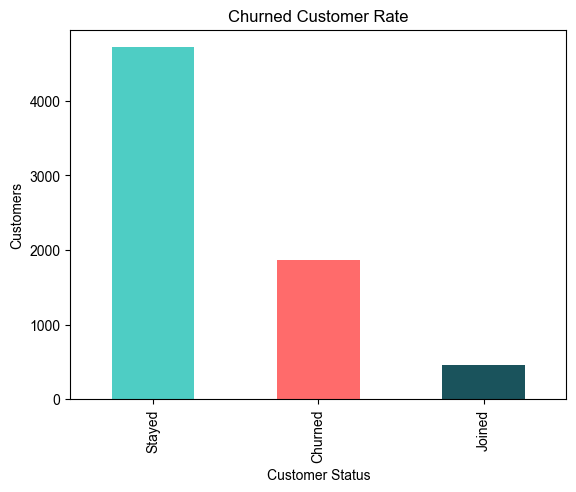

In [53]:
#Churn Rate Overview
churn_rate = df["Customer Status"].value_counts()
churn_rate.plot(kind='bar', color=['#4ecdc4', '#ff6b6b', '#1a535c'])
plt.title("Churned Customer Rate")
plt.xlabel("Customer Status")
plt.ylabel("Customers")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.show()

## Insight:
The customer status distribution shows that approximately 26.5% of customers have churned, indicating a significant retention challenge. While a majority of customers remain active, the churn rate suggests that the company must investigate key drivers of customer attrition to protect long-term revenue stability.

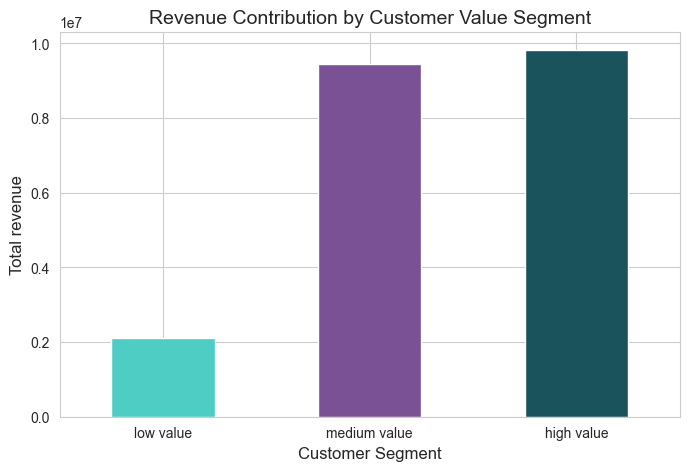

In [54]:
#Revenue Contribution by Value Segment
order = ["low value", "medium value", "high value"]
revenue_segment = df.groupby("Value_Segment")["Total Revenue"].sum().reindex(order)
revenue_segment.plot(kind = 'bar', color=['#4ecdc4', '#7a5195', '#1a535c'])
plt.title("Revenue Contribution by Customer Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total revenue")
plt.xticks(rotation=0)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.show()

## Insight:
Revenue analysis reveals that high-value customers contribute a disproportionately large share of total revenue, despite representing a smaller portion of the customer base. This indicates strong revenue concentration and highlights the importance of protecting high-value customers from churn.

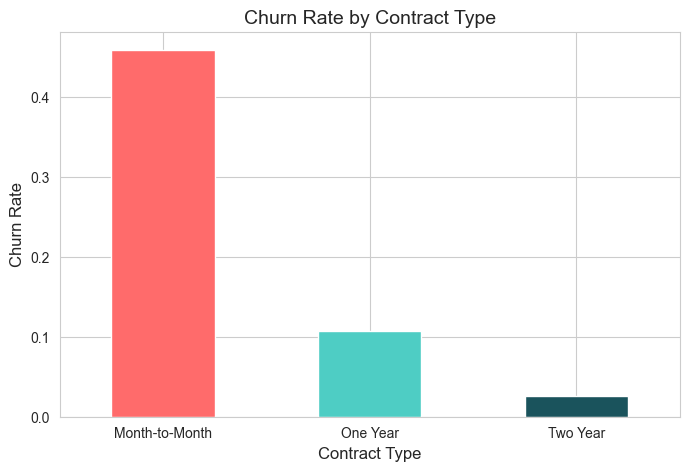

In [55]:
#Churn Rate by Contract Type
churn_contract = df.groupby("Contract")["Churn Flag"].mean().sort_values(ascending=False)
churn_contract.plot(kind = 'bar', color=['#ff6b6b', '#4ecdc4', '#1a535c'])
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.show()

## Insight:
Contract analysis reveals that customers on month-to-month contracts experience significantly higher churn (~46%) compared to those on one-year or two-year contracts. This indicates that longer contractual commitments play a critical role in improving customer retention.

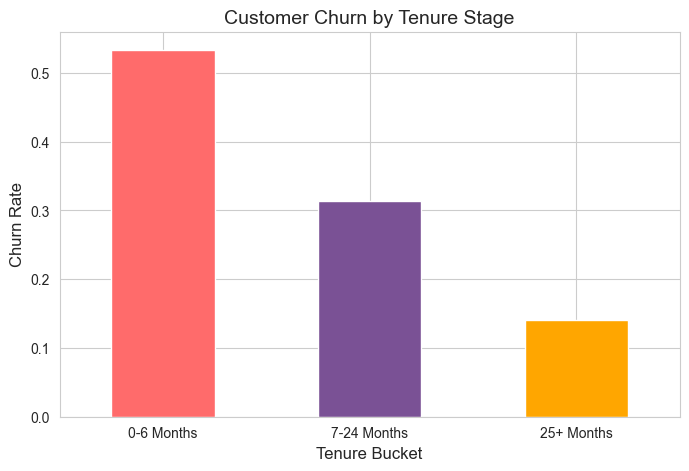

In [56]:
#Churn Rate by Contract Type
order = ["0-6 Months", "7-24 Months", "25+ Months"]
tenure_churn = df.groupby("Tenure Bucket")["Churn Flag"].mean().reindex(order)
tenure_churn.plot(kind='bar',color=['#ff6b6b','#7a5195','#ffa600'])
plt.title("Customer Churn by Tenure Stage")
plt.xlabel("Tenure Bucket")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.show()

## Insight:
Customer lifecycle analysis shows that churn is highest during the first six months (~53%), suggesting that early customer experience or onboarding may influence long-term retention. Customers who remain beyond two years demonstrate significantly lower churn rates.

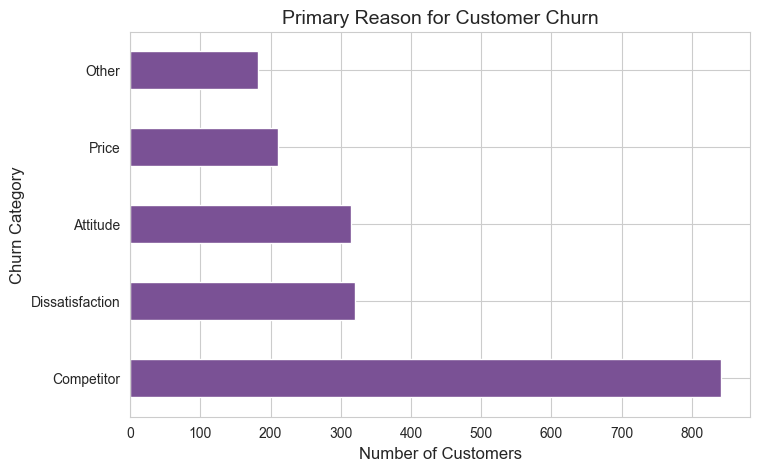

In [57]:
#Churn Reasons
churn_reason = df[df["Customer Status"] == "Churned"]["Churn Category"].value_counts().plot(kind='barh',color = '#7a5195')
plt.title("Primary Reason for Customer Churn")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Category")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.show()

## Insight:
Churn reason analysis indicates that competitor-related factors are the leading cause of churn, followed by dissatisfaction and service-related issues. This suggests that competitive pricing, service offerings, and customer experience play a major role in customer retention.

# Advanced Analysis

In [56]:
#1. Revenue at Risk Analysis
total_revenue = df['Total Revenue'].sum()

churned_revenue = df[df['Churn Flag'] == 1]['Total Revenue'].sum()

revenue_at_risk_pct = (churned_revenue/total_revenue)*100

total_revenue, churned_revenue, revenue_at_risk_pct

(np.float64(21371131.69),
 np.float64(3684459.8200000003),
 np.float64(17.240358973240692))

### Inisght:
Churned customers contribute 17.24% of total revenue (~3.68M), indicating a significant portion of business revenue is at risk. This highlights that even a moderate churn rate can have a substantial financial impact, making customer retention a critical business priority.

In [64]:
#2. High-Risk Segment Analysis
# Revenue Loss by Segment (Data-Driven)

segment_analysis = (
    df[df['Churn Flag'] == 1]
    .groupby(['Contract', 'Tenure Bucket', 'Value_Segment'])
    .agg({'Total Revenue': 'sum'})
    .reset_index()
    .sort_values(by='Total Revenue', ascending=False)
)

print(segment_analysis.head(5))

          Contract Tenure Bucket Value_Segment  Total Revenue
3   Month-to-Month    25+ Months    high value      981652.13
5   Month-to-Month    25+ Months  medium value      563206.95
12        One Year    25+ Months    high value      551145.74
8   Month-to-Month   7-24 Months  medium value      397915.21
6   Month-to-Month   7-24 Months    high value      293044.25


### Insight:
High-value customers on month-to-month contracts with long tenure (25+ months) contribute the highest revenue loss (~981K), indicating that even long-term loyal customers are churning. This suggests potential issues in pricing, competition, or service experience, making this segment the highest priority for retention strategies.

In [57]:
#3. Revenue Loss by Customer Segment
segment_loss = df[df['Customer Status'] == 'Churned'].groupby('Value_Segment').agg(
    churned_customers = ('Customer ID', 'count'),
    revenue_loss = ('Total Revenue','sum')
).reset_index().sort_values(by='revenue_loss', ascending= False)

segment_loss

,Value_Segment,churned_customers,revenue_loss
0,high value,587,2094435.66
2,medium value,1003,1443016.86
1,low value,279,147007.30


### Inisght:
High-value customers contribute the largest share of revenue loss (~$2.09M), significantly higher than medium and low-value segments. Despite being smaller in number, their financial impact is disproportionately high, making them the top priority for retention strategies.

In [59]:
#4. Revenue Loss by Churn Category
churn_category_analysis = (
    df[df['Churn Flag'] ==1]
    .groupby('Churn Category')
    .agg({'Total Revenue':'sum'})
    .reset_index()
    .sort_values(by='Total Revenue', ascending=False)
)
total_churn_revenue = churn_category_analysis['Total Revenue'].sum()

churn_category_analysis['Revenue Loss %'] = (
    churn_category_analysis['Total Revenue']/ total_churn_revenue*100
)

churn_category_analysis

,Churn Category,Total Revenue,Revenue Loss %
1,Competitor,1694413.15,45.988102
2,Dissatisfaction,617979.26,16.772588
0,Attitude,579554.13,15.729691
4,Price,438124.14,11.891136
3,Other,354389.14,9.618483


### Inisght:
Competitor-driven churn accounts for ~46% of total revenue loss, making it the dominant cause of financial leakage. This indicates that competitive offerings, pricing, or service quality are key drivers of customer attrition and should be prioritized in retention strategies.

### Key Findings

1. The telecom company experiences a churn rate of approximately 26.5%, impacting approximately USD 3.68M in revenue, indicating a significant retention challenge.
2. High-value customers contribute the largest share of revenue loss $2.09M, making them the most important segment for retention despite being smaller in number.
3. Although overall revenue at risk is ~17%, churn is concentrated among high-value and medium-value segments, indicating financial vulnerability in core revenue drivers.
4. Customers on month-to-month contracts exhibit significantly higher churn (~46%), highlighting low contractual commitment as a key risk factor.
5. Churn is highest during the first 6 months of the customer lifecycle (~53%), suggesting onboarding and early customer experience gaps.
6. While churn rates are highest in early tenure, the financial impact is significantly greater among long-tenure high-value customers, making them a higher priority segment for retention.
7. The largest driver of churn is competitor-related switching (~46%), indicating strong external market pressure and the need for competitive differentiation.

## Business Recommendations

1. Introduce targeted incentives to convert high-value month-to-month customers into long-term contracts, as this segment contributes the highest revenue loss.
2. Strengthen retention strategies for long-tenure high-value customers (25+ months), as churn within this segment contributes disproportionately to overall revenue loss.
3. Address competitor-driven churn (~46%) by improving pricing strategies, service offerings, and bundled plans to remain competitive in the market.
4. Implement targeted retention campaigns for high-value customers showing churn signals, especially those on flexible contracts.
5. Continuously monitor churn drivers and segment-level revenue loss to enable proactive and data-driven retention strategies.

In [58]:
df.to_csv("telecomm_cleaned_data.csv", index=False)